In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the master dataset
master_df = pd.read_csv('../data/master_df.csv')

# Quick check
print(f"Dataset shape: {master_df.shape}")
print(f"\nPositions: {sorted(master_df['position'].unique())}")
print(f"Seasons: {master_df['season'].min()} - {master_df['season'].max()}")
print(f"Unique players: {master_df['player_name'].nunique()}")
master_df.head()

Dataset shape: (3348, 74)

Positions: ['K', 'LB', 'P', 'QB', 'RB', 'TE', 'WR']
Seasons: 2018 - 2023
Unique players: 1208


,player_id,season,season_type,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,...,team_x,weight,height,team_y,year_signed,years,value,aav,guaranteed,draft_overall
0,00-0039165,2023,REG,0,0,0.0,0,0.0,0.0,0.0,...,SEA,220.0,73.0,Seahawks,2023,4.0,6.876078,1.71902,3.813333,52.0
1,00-0035831,2023,REG,0,0,0.0,0,0.0,0.0,0.0,...,NO,220.0,69.0,Packers,2023,1.0,0.289800,0.28980,0.000000,NaN
2,00-0035860,2023,REG,0,0,0.0,0,0.0,0.0,0.0,...,ARI,225.0,71.0,Saints,2023,1.0,0.315000,0.31500,0.000000,NaN
3,00-0030431,2023,REG,0,0,0.0,0,0.0,0.0,0.0,...,HOU,193.0,72.0,Texans,2023,2.0,15.250000,7.62500,10.000000,41.0
4,00-0035859,2023,REG,0,0,0.0,0,0.0,0.0,0.0,...,ARI,196.0,74.0,Cardinals,2023,1.0,0.940000,0.94000,0.000000,NaN


/var/folders/6w/pjn5hnkd5712p8r0ytbwcnt40000gn/T/ipykernel_57976/1275408433.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=avg_aav, x='position', y='aav', palette='Blues_d')


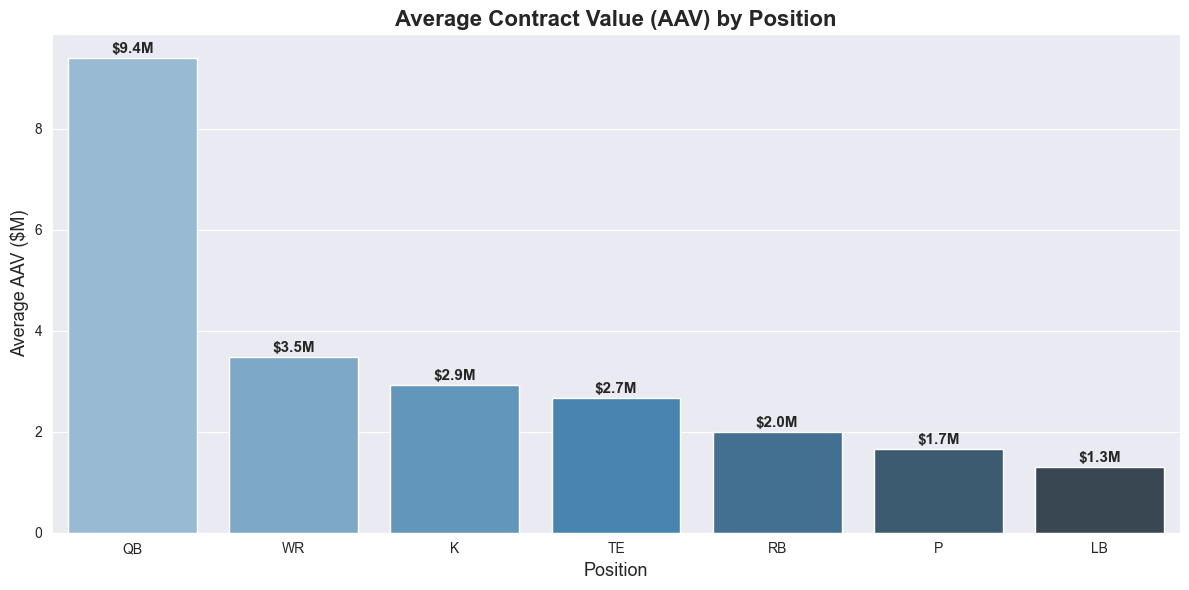


Exact averages:
position      aav
      QB 9.394280
      WR 3.481004
       K 2.922971
      TE 2.667121
      RB 2.002860
       P 1.652078
      LB 1.293213


In [6]:
# Set the chart style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Average AAV by position
avg_aav = master_df.groupby('position')['aav'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=avg_aav, x='position', y='aav', palette='Blues_d')

# Add value labels on top of each bar
for bar, val in zip(bars.patches, avg_aav['aav']):
    bars.text(bar.get_x() + bar.get_width()/2, 
              bar.get_height() + 0.1, 
              f'${val:.1f}M', 
              ha='center', fontsize=11, fontweight='bold')

plt.title('Average Contract Value (AAV) by Position', fontsize=16, fontweight='bold')
plt.xlabel('Position', fontsize=13)
plt.ylabel('Average AAV ($M)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/avg_aav_by_position.png', dpi=150)
plt.show()

print("\nExact averages:")
print(avg_aav.to_string(index=False))

/var/folders/6w/pjn5hnkd5712p8r0ytbwcnt40000gn/T/ipykernel_57976/1749404326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='position', y='aav', palette='Blues_d')


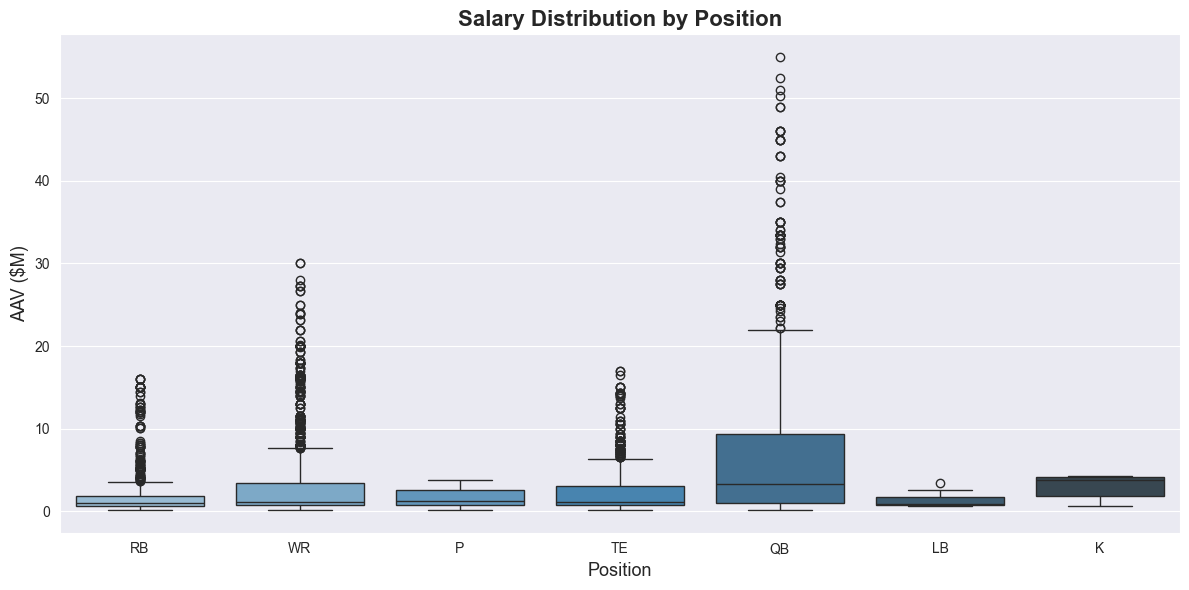


Salary stats by position:
           count  mean    std   min   25%   50%   75%    max
position                                                    
K            7.0  2.92   1.62  0.64  1.80  3.80  4.11   4.20
LB          17.0  1.29   0.83  0.57  0.70  0.92  1.75   3.40
P           64.0  1.65   1.08  0.13  0.76  1.19  2.59   3.75
QB         464.0  9.39  12.78  0.13  0.99  3.25  9.40  55.00
RB         814.0  2.00   2.89  0.13  0.65  0.98  1.80  16.02
TE         699.0  2.67   3.33  0.13  0.75  1.06  3.00  17.00
WR        1283.0  3.48   5.26  0.13  0.69  1.10  3.47  30.00


In [7]:
# Salary distribution by position
plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df, x='position', y='aav', palette='Blues_d')

plt.title('Salary Distribution by Position', fontsize=16, fontweight='bold')
plt.xlabel('Position', fontsize=13)
plt.ylabel('AAV ($M)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/salary_distribution_by_position.png', dpi=150)
plt.show()

print("\nSalary stats by position:")
print(master_df.groupby('position')['aav'].describe().round(2))

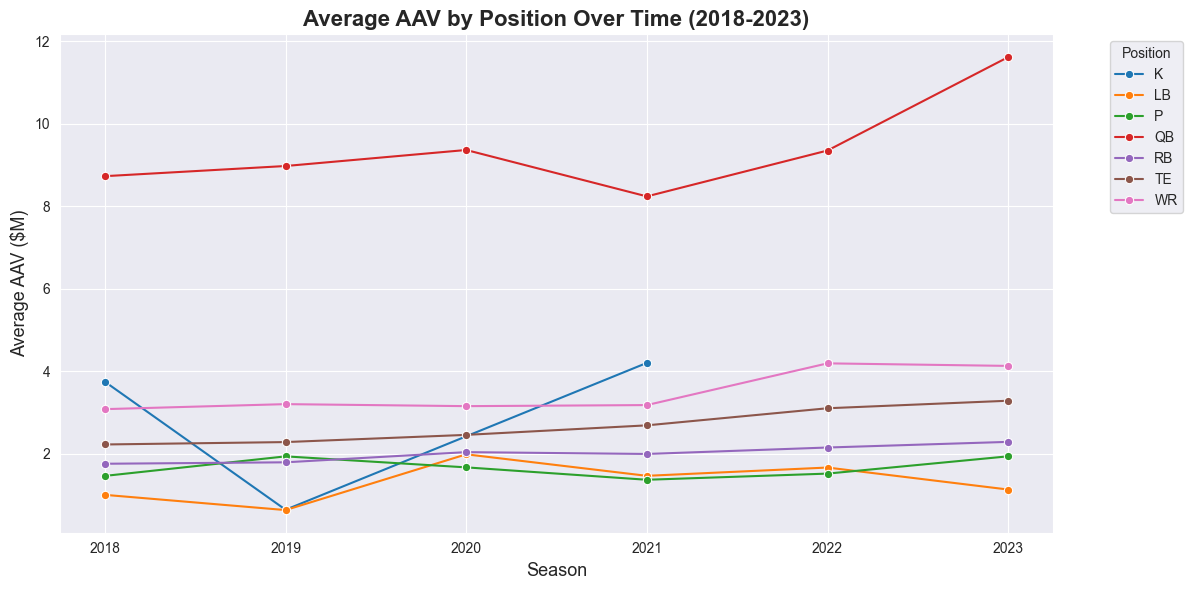

In [8]:
# Average AAV per position over the years
avg_aav_year = master_df.groupby(['season', 'position'])['aav'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_aav_year, x='season', y='aav', 
             hue='position', marker='o', palette='tab10')

plt.title('Average AAV by Position Over Time (2018-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=13)
plt.ylabel('Average AAV ($M)', fontsize=13)
plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/aav_over_time.png', dpi=150)
plt.show()

In [9]:
# Calculate average AAV per position as the baseline
position_avg = master_df.groupby('position')['aav'].mean()

# Add position average to each player row
master_df['position_avg_aav'] = master_df['position'].map(position_avg)

# Calculate value delta — positive = overpaid, negative = underpaid
master_df['value_delta'] = master_df['aav'] - master_df['position_avg_aav']

# Top 10 most overpaid players
print("💰 TOP 10 MOST OVERPAID PLAYERS:")
overpaid = master_df[['player_name', 'position', 'season', 'aav', 
                       'position_avg_aav', 'value_delta']]\
                       .sort_values('value_delta', ascending=False).head(10)
print(overpaid.to_string(index=False))

print("\n\n🔥 TOP 10 MOST UNDERPAID PLAYERS:")
underpaid = master_df[['player_name', 'position', 'season', 'aav', 
                        'position_avg_aav', 'value_delta']]\
                        .sort_values('value_delta', ascending=True).head(10)
print(underpaid.to_string(index=False))

💰 TOP 10 MOST OVERPAID PLAYERS:
   player_name position  season       aav  position_avg_aav  value_delta
    Joe Burrow       QB    2023 55.000000           9.39428    45.605720
Justin Herbert       QB    2023 52.500000           9.39428    43.105720
   Jalen Hurts       QB    2023 51.000000           9.39428    41.605720
 Aaron Rodgers       QB    2022 50.271667           9.39428    40.877387
Russell Wilson       QB    2023 49.000000           9.39428    39.605720
Russell Wilson       QB    2022 49.000000           9.39428    39.605720
  Kyler Murray       QB    2022 46.100000           9.39428    36.705720
  Kyler Murray       QB    2023 46.100000           9.39428    36.705720
Deshaun Watson       QB    2022 46.000000           9.39428    36.605720
Deshaun Watson       QB    2023 46.000000           9.39428    36.605720


🔥 TOP 10 MOST UNDERPAID PLAYERS:
    player_name position  season    aav  position_avg_aav  value_delta
     Kyle Allen       QB    2018 0.1292           9.39428  

/var/folders/6w/pjn5hnkd5712p8r0ytbwcnt40000gn/T/ipykernel_57976/1667092309.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overpaid_plot, x='value_delta', y='player_name',
/var/folders/6w/pjn5hnkd5712p8r0ytbwcnt40000gn/T/ipykernel_57976/1667092309.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=underpaid_plot, x='value_delta', y='player_name',


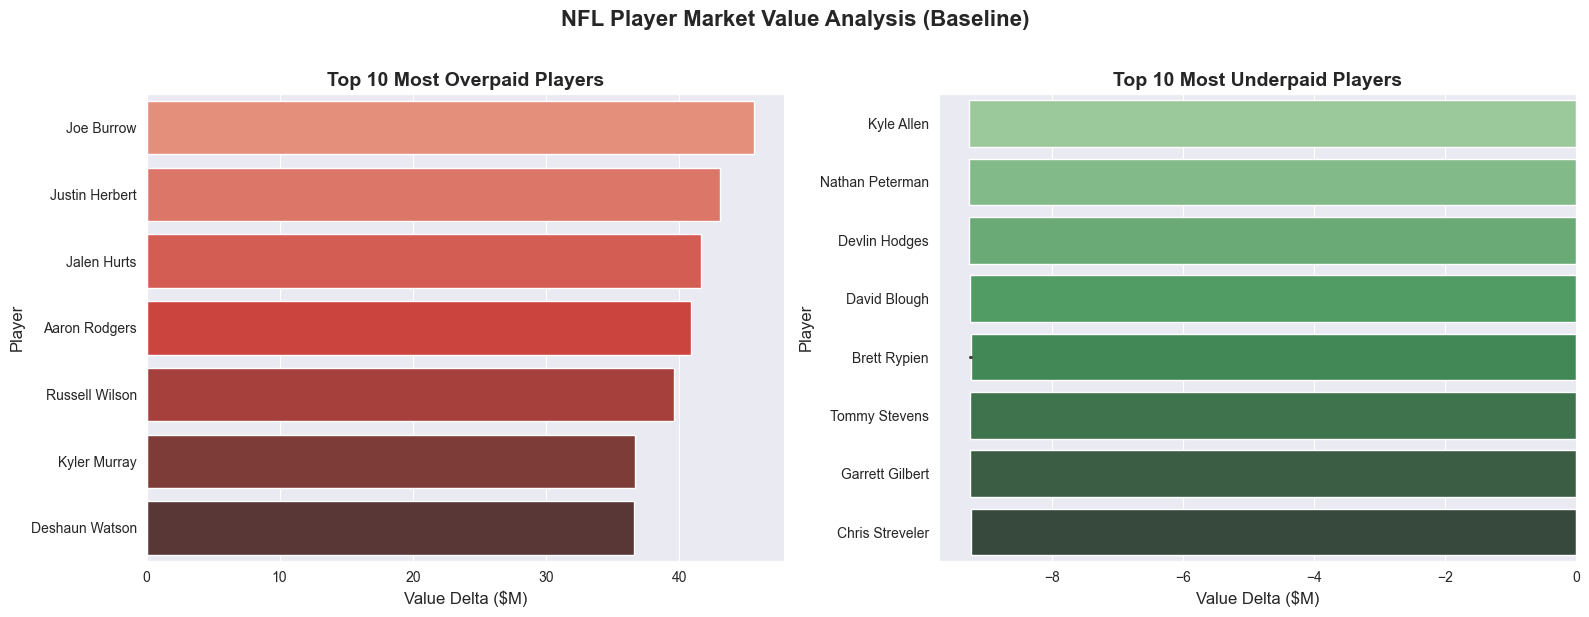

In [10]:
# Top 10 overpaid and underpaid players visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 overpaid
overpaid_plot = master_df.nlargest(10, 'value_delta')[['player_name', 'value_delta']]
sns.barplot(data=overpaid_plot, x='value_delta', y='player_name', 
            palette='Reds_d', ax=axes[0])
axes[0].set_title('Top 10 Most Overpaid Players', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Value Delta ($M)', fontsize=12)
axes[0].set_ylabel('Player', fontsize=12)

# Top 10 underpaid
underpaid_plot = master_df.nsmallest(10, 'value_delta')[['player_name', 'value_delta']]
sns.barplot(data=underpaid_plot, x='value_delta', y='player_name', 
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Top 10 Most Underpaid Players', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Value Delta ($M)', fontsize=12)
axes[1].set_ylabel('Player', fontsize=12)

plt.suptitle('NFL Player Market Value Analysis (Baseline)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/overpaid_underpaid_baseline.png', dpi=150)
plt.show()

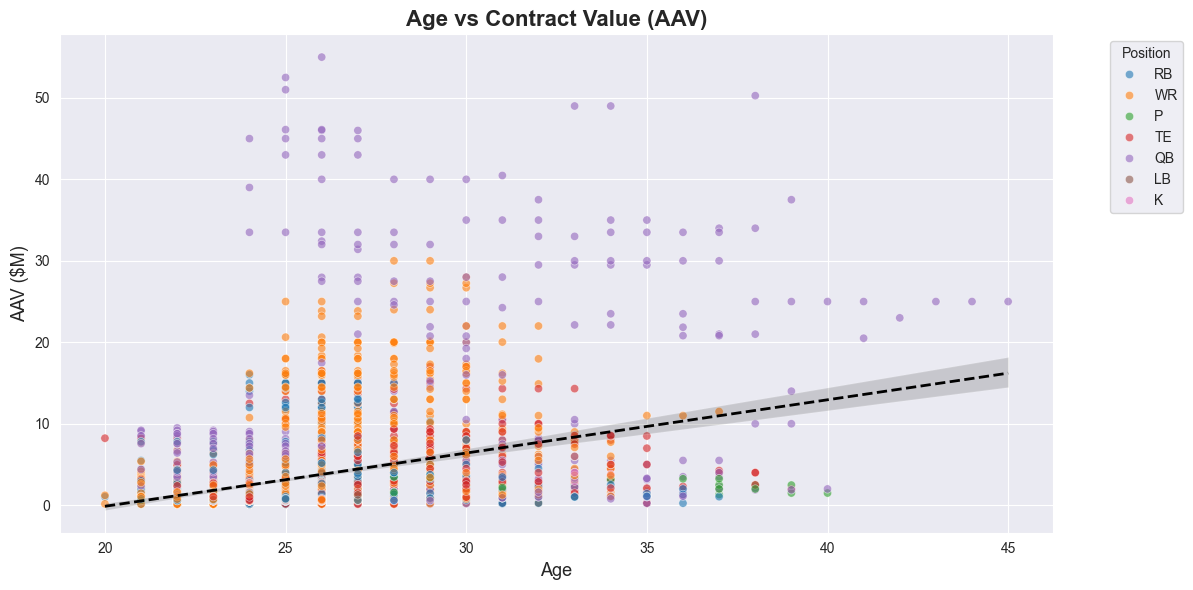


Correlation between Age and AAV: 0.340


In [11]:
# How does age affect AAV?
plt.figure(figsize=(12, 6))
sns.scatterplot(data=master_df, x='age', y='aav', 
                hue='position', alpha=0.6, palette='tab10')

# Add a trend line
sns.regplot(data=master_df, x='age', y='aav', 
            scatter=False, color='black', 
            line_kws={'linewidth': 2, 'linestyle': '--', 'label': 'Trend'})

plt.title('Age vs Contract Value (AAV)', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=13)
plt.ylabel('AAV ($M)', fontsize=13)
plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/age_vs_aav.png', dpi=150)
plt.show()

# Correlation between age and AAV
correlation = master_df['age'].corr(master_df['aav'])
print(f"\nCorrelation between Age and AAV: {correlation:.3f}")

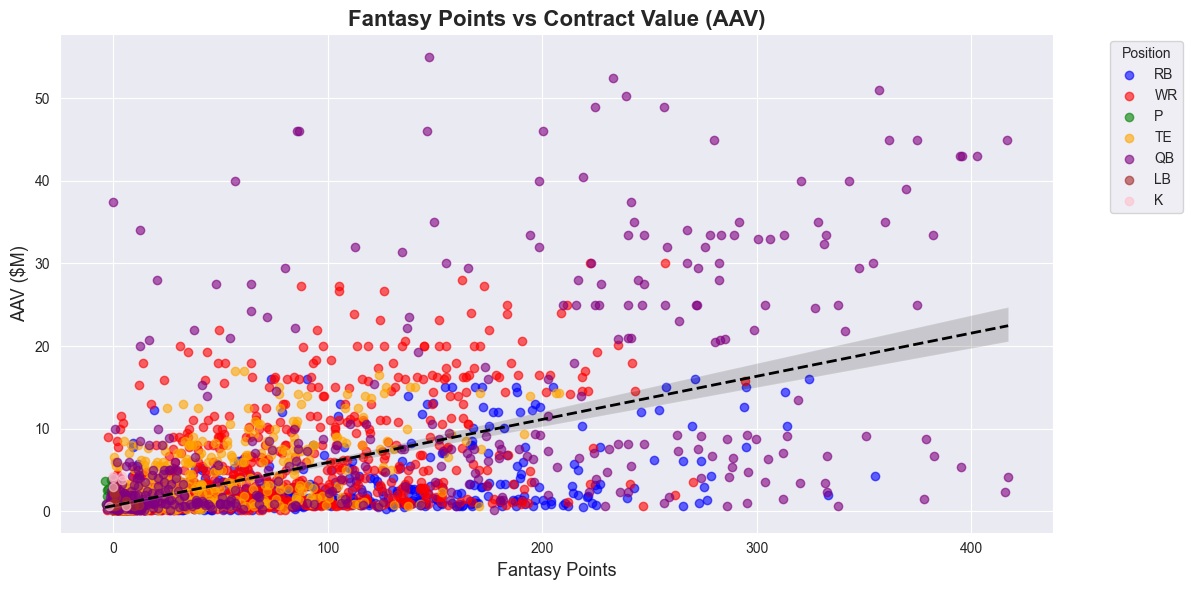


Correlation between Fantasy Points and AAV: 0.578


In [12]:
# Fantasy points vs AAV by position
plt.figure(figsize=(12, 6))

positions = master_df['position'].unique()
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']

for pos, color in zip(positions, colors):
    subset = master_df[master_df['position'] == pos]
    plt.scatter(subset['fantasy_points'], subset['aav'], 
                label=pos, alpha=0.6, color=color)

# Add trend line
sns.regplot(data=master_df, x='fantasy_points', y='aav',
            scatter=False, color='black',
            line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Fantasy Points vs Contract Value (AAV)', fontsize=16, fontweight='bold')
plt.xlabel('Fantasy Points', fontsize=13)
plt.ylabel('AAV ($M)', fontsize=13)
plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/fantasy_points_vs_aav.png', dpi=150)
plt.show()

# Correlation
correlation = master_df['fantasy_points'].corr(master_df['aav'])
print(f"\nCorrelation between Fantasy Points and AAV: {correlation:.3f}")

In [13]:
# Save updated master df with value delta column
master_df.to_csv('../data/master_df.csv', index=False)
print("✅ Master dataset updated and saved!")

print("\n📊 Phase 2 Summary:")
print(f"Total visualizations created: 5")
print(f"Key findings:")
print(f"  - QBs are the highest paid position by far")
print(f"  - Age vs AAV correlation: 0.340 (moderate)")
print(f"  - Fantasy Points vs AAV correlation: 0.578 (stronger)")
print(f"  - Performance is a better predictor of salary than age")
print(f"  - Baseline shows stars vs backups gap")
print(f"  - Phase 3 ML model will find true market inefficiencies")

✅ Master dataset updated and saved!

📊 Phase 2 Summary:
Total visualizations created: 5
Key findings:
  - QBs are the highest paid position by far
  - Age vs AAV correlation: 0.340 (moderate)
  - Fantasy Points vs AAV correlation: 0.578 (stronger)
  - Performance is a better predictor of salary than age
  - Baseline shows stars vs backups gap
  - Phase 3 ML model will find true market inefficiencies
